# 05 - Diagnostics

Two methodological checks that support the modelling choices:

1. **Within / between decomposition** of the static regression coefficients ,
   splitting each regressor's variation into a high-frequency (within a rolling
   window) and a low-frequency (across windows) part, to show that the pooled
   OLS coefficient mixes two different time scales.
2. **Augmented Dickey-Fuller (ADF)** stationarity tests, to gauge the
   persistence of each series (relevant because a strong low-frequency /
   between relationship on a highly persistent regressor carries spurious-
   regression risk).

This notebook only reports statistics; it draws no substantive conclusions.

## Setup

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

import safe_haven as sh
from safe_haven import CURRENCIES, REGRESSORS, FIG_DIR, PAPER_DIR

WINDOW = 252            # 1-year rolling window

## Load and construct variables

Same construction as notebooks 02-04, from the shared `safe_haven.py`.

In [2]:
data = sh.load_data()
model_frame = data.model_frame
excess, fx_vol = data.excess, data.fx_vol
sp500_d, ust10y_d, ted, vix_d = data.sp500_d, data.ust10y_d, data.ted, data.vix_d

## 1. Within / between decomposition

For each currency: the pooled OLS coefficient (**FULL**), the coefficient from
deviations around a 1-year rolling mean (**WITHIN**, high-frequency), and the
coefficient from the rolling means themselves (**BETWEEN**, low-frequency).

In [3]:
def within_between(cur):
    df = model_frame(cur)
    cols = ["excess"] + REGRESSORS
    lo = df[cols].rolling(WINDOW).mean().dropna()
    hi = (df[cols] - df[cols].rolling(WINDOW).mean()).dropna()
    full = sm.OLS(df["excess"], sm.add_constant(df[REGRESSORS])).fit().params
    within = sm.OLS(hi["excess"], sm.add_constant(hi[REGRESSORS])).fit().params
    between = sm.OLS(lo["excess"], sm.add_constant(lo[REGRESSORS])).fit().params
    return pd.DataFrame({"FULL": full[REGRESSORS],
                         "WITHIN": within[REGRESSORS],
                         "BETWEEN": between[REGRESSORS]}).round(3)

wb = pd.concat({cur: within_between(cur) for cur in CURRENCIES}, axis=1)
wb

CHF                   EUR                   GBP                 \
         FULL WITHIN BETWEEN   FULL WITHIN BETWEEN   FULL WITHIN BETWEEN   
SP500   0.030  0.028   0.124  0.068  0.069   0.166  0.085  0.087   0.265   
UST10Y -0.022 -0.021  -0.040 -0.013 -0.012  -0.032 -0.008 -0.008  -0.035   
fxvol   0.000  0.000   0.001  0.000  0.000   0.000  0.000  0.000   0.000   
TED    -0.066 -0.152  -0.065 -0.084 -0.231  -0.011 -0.215 -0.357  -0.094   
VIX     0.004  0.004   0.037  0.002  0.002   0.020  0.000  0.000   0.018   

          JPY                 
         FULL WITHIN BETWEEN  
SP500  -0.009 -0.016   0.162  
UST10Y -0.035 -0.036  -0.062  
fxvol   0.001  0.000   0.001  
TED     0.119  0.118   0.091  
VIX     0.009  0.008   0.027

### Low-frequency variance share

Share of each regressor's variance carried by the 1-year rolling mean, a simple
persistence gauge. A near-zero share means the regressor is essentially
high-frequency; a large share means it is dominated by slow movements.

In [4]:
def lowfreq_share(cur):
    df = model_frame(cur)
    out = {}
    for r in REGRESSORS:
        s = df[r]
        lo = s.rolling(WINDOW).mean()
        out[r] = lo.var() / s.loc[lo.dropna().index].var()
    return pd.Series(out)

share = pd.DataFrame({cur: lowfreq_share(cur) for cur in CURRENCIES}).round(3)
share

,CHF,EUR,GBP,JPY
SP500,0.003,0.003,0.003,0.003
UST10Y,0.003,0.003,0.003,0.003
fxvol,0.556,0.542,0.610,0.555
TED,0.620,0.620,0.620,0.616
VIX,0.001,0.001,0.001,0.001


## 2. ADF stationarity tests

Augmented Dickey-Fuller test (H0: unit root / non-stationary). A small p-value
rejects the unit root, i.e. indicates stationarity. Tested for the excess
returns, the per-currency fx volatility, and the shared regressors.

In [5]:
def adf_row(name, s):
    stat, p, *_ = adfuller(s.dropna(), autolag="AIC")
    return {"series": name, "ADF": round(stat, 2), "p-value": round(p, 4),
            "stationary@5%": p < 0.05}

rows = []
for cur in CURRENCIES:
    rows.append(adf_row(f"excess_{cur}", excess[cur]))
for cur in CURRENCIES:
    rows.append(adf_row(f"fxvol_{cur}", fx_vol[cur]))
for name, s in [("SP500", sp500_d), ("VIX", vix_d), ("UST10Y", ust10y_d), ("TED", ted)]:
    rows.append(adf_row(name, s))

adf = pd.DataFrame(rows).set_index("series")
adf

,ADF,p-value,stationary@5%
series,,,
excess_CHF,-17.56,0.0000,True
excess_EUR,-35.25,0.0000,True
excess_GBP,-17.14,0.0000,True
excess_JPY,-54.20,0.0000,True
fxvol_CHF,-4.10,0.0010,True
fxvol_EUR,-4.11,0.0009,True
fxvol_GBP,-3.93,0.0018,True
fxvol_JPY,-3.97,0.0016,True
SP500,-14.39,0.0000,True


## 3. Multicollinearity (VIF)

Variance inflation factor per regressor (computed per currency, since fx
volatility is currency-specific). Common thresholds: VIF > 5 (moderate) or
> 10 (severe) signal problematic collinearity.

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif(cur):
    X = sm.add_constant(model_frame(cur)[REGRESSORS]).values
    return pd.Series(
        {REGRESSORS[i - 1]: variance_inflation_factor(X, i) for i in range(1, X.shape[1])})

vif_table = pd.DataFrame({cur: vif(cur) for cur in CURRENCIES}).round(2)
vif_table

,CHF,EUR,GBP,JPY
SP500,2.24,2.24,2.24,2.25
UST10Y,1.10,1.10,1.10,1.10
fxvol,1.16,1.16,1.13,1.10
TED,1.16,1.16,1.13,1.11
VIX,2.16,2.16,2.16,2.16


## 4. DLM innovation diagnostics

State-space model check (the course's *innovation-based model checking*). If the
DLM is well specified, the standardized one-step-ahead forecast errors
(innovations $e_t$) should be **white noise** and **standard normal**.
**Ljung-Box** tests residual autocorrelation up to lag 10 (H0: none);
**Jarque-Bera** tests normality (H0: normal). The DLM is refitted here as in
notebook 04.

In [7]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

def fit_dlm(cur, lam=sh.LAMBDA):
    df = model_frame(cur)
    res, _ = sh.dlm_fit(df, lam)
    return df, res

rows = []
for cur in CURRENCIES:
    _, res = fit_dlm(cur)
    e = pd.Series(res.standardized_forecasts_error[0]).replace([np.inf, -np.inf], np.nan).dropna()
    rows.append({
        "currency": cur,
        "Ljung-Box(10) p": round(acorr_ljungbox(e, lags=[10])["lb_pvalue"].iloc[0], 4),
        "Jarque-Bera p": f"{stats.jarque_bera(e)[1]:.2g}",
    })
innovation = pd.DataFrame(rows).set_index("currency")
innovation

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Ljung-Box(10) p,Jarque-Bera p
currency,,
CHF,0.0294,0
EUR,0.3632,0
GBP,0.0017,0
JPY,0.0002,0


Both tests reject for all currencies (p ≈ 0): the standardized innovations show
residual autocorrelation and are non-normal (heavy-tailed), a common feature of
daily financial return data (volatility clustering, fat tails), which the
constant-variance Gaussian observation model does not capture.

## 5. DLM smoothness sensitivity ($\lambda$)

The fx-volatility coefficient path under a range of smoothness priors $\lambda$
(larger $\lambda$ allows more time variation). This checks that the qualitative
shape of the path is not an artefact of the chosen $\lambda$.

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


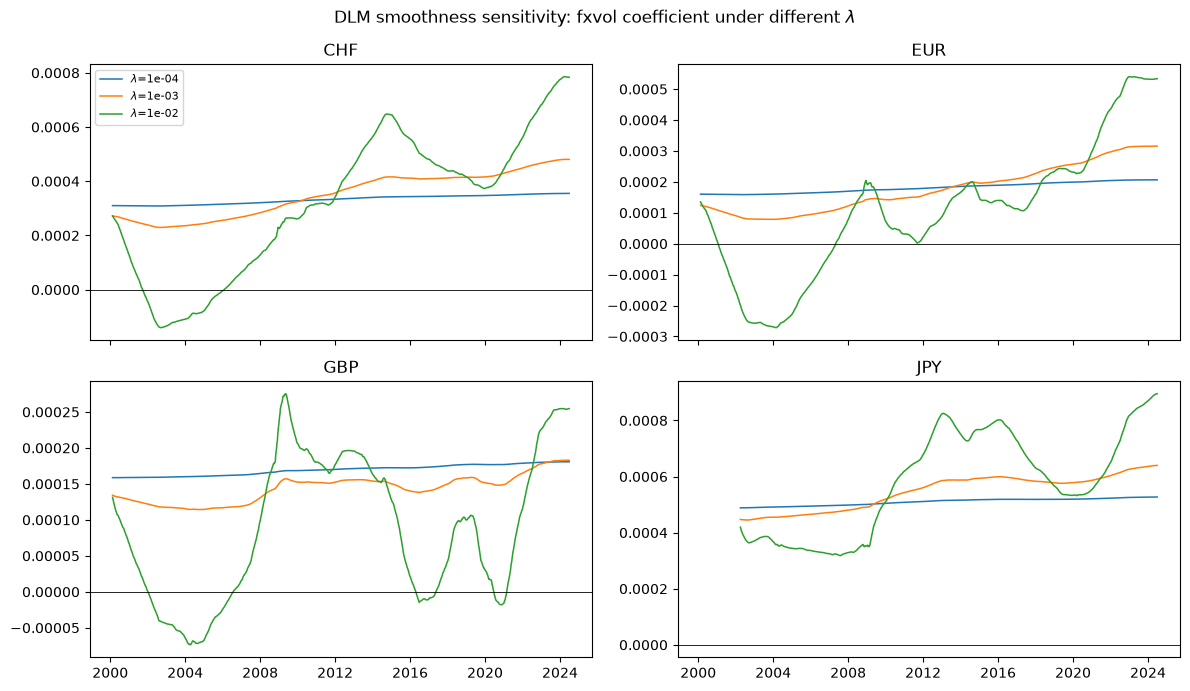

In [8]:
import matplotlib.pyplot as plt

LAMBDAS = [1e-4, 1e-3, 1e-2]
COEF = "fxvol"
j = (["const"] + REGRESSORS).index(COEF)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, cur in zip(axes.ravel(), CURRENCIES):
    for lam in LAMBDAS:
        df, res = fit_dlm(cur, lam)
        path = pd.Series(res.smoothed_state[j], index=df.index)
        ax.plot(path.index, path, lw=1.1, label=fr"$\lambda$={lam:.0e}")
    ax.axhline(0, color="black", lw=0.6)
    ax.set_title(cur)
axes.ravel()[0].legend(fontsize=8)
fig.suptitle(fr"DLM smoothness sensitivity: {COEF} coefficient under different $\lambda$")
fig.tight_layout()

FIG_DIR.mkdir(exist_ok=True)
fig.savefig(FIG_DIR / "dlm_lambda_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

## Export tables to LaTeX

Write the diagnostics tables (within/between, ADF, VIF, DLM innovations) to
`../paper/` for inclusion in the paper via `\input{}`.

In [9]:
PAPER = PAPER_DIR; PAPER.mkdir(exist_ok=True)

def _esc(s): return str(s).replace("_", r"\_")
def _tbl(caption, label, header, rows, align):
    return "\n".join([r"\begin{table}[H]", r"\centering", rf"\caption{{{caption}}}",
        rf"\label{{{label}}}", rf"\begin{{tabular}}{{{align}}}", r"\toprule",
        header + r" \\", r"\midrule"] + rows + [r"\bottomrule", r"\end{tabular}", r"\end{table}"])

wb_rows = []
for cur in CURRENCIES:
    d = within_between(cur)
    for reg in REGRESSORS:
        wb_rows.append(f"{cur} & {reg} & ${d.loc[reg,'FULL']:.3f}$ & "
                       f"${d.loc[reg,'WITHIN']:.3f}$ & ${d.loc[reg,'BETWEEN']:.3f}$ " + r"\\")
    if cur != CURRENCIES[-1]: wb_rows.append(r"\midrule")
(PAPER/"withinbetween.tex").write_text(_tbl(
    "Within/between decomposition of the static coefficients. FULL = pooled OLS; "
    "WITHIN = deviations from a 1-year rolling mean; BETWEEN = rolling means.",
    "tab:withinbetween", "Currency & Regressor & FULL & WITHIN & BETWEEN", wb_rows, "llrrr"))

adf_rows = [f"{_esc(n)} & ${row['ADF']:.2f}$ & ${row['p-value']:.3f}$ & "
            f"{'yes' if row['stationary@5%'] else 'no'} " + r"\\" for n, row in adf.iterrows()]
(PAPER/"adf.tex").write_text(_tbl(
    "Augmented Dickey-Fuller tests (H0: unit root). Small $p$ indicates stationarity.",
    "tab:adf", r"Series & ADF & $p$-value & Stationary (5\%)", adf_rows, "lrrl"))

vif_rows = [f"{reg} & " + " & ".join(f"${vif_table.loc[reg,cur]:.2f}$" for cur in CURRENCIES) + r" \\"
            for reg in REGRESSORS]
(PAPER/"vif.tex").write_text(_tbl(
    "Variance inflation factors (per currency). Values below 5 indicate no problematic collinearity.",
    "tab:vif", "Regressor & " + " & ".join(CURRENCIES), vif_rows, "lrrrr"))

inn_rows = [f"{cur} & ${_esc(row.iloc[0])}$ & ${_esc(row.iloc[1])}$ " + r"\\"
            for cur, row in innovation.iterrows()]
(PAPER/"innovations.tex").write_text(_tbl(
    r"DLM innovation diagnostics: Ljung-Box (lag 10) and Jarque-Bera $p$-values on the "
    r"standardized one-step-ahead forecast errors.",
    "tab:innovations", r"Currency & Ljung-Box $p$ & Jarque-Bera $p$", inn_rows, "lrr"))
print("Wrote diagnostics tables to paper/")

Wrote diagnostics tables to paper/
